## Assetwise sign-in

In order to use chrome from your scripting, you should download the relevant [chrome driver](https://googlechromelabs.github.io/chrome-for-testing/#stable) (chromedriver, not chrome!) for your current version of google chrome, then add the path to the driver to your script below.

In [ ]:
# User Configuration
user_email = "dane.parks@dot.ohio.gov"
path_to_excel = r"C:\Users\dparks1\Desktop\assetwise_script_demo\reportSummaryData.xlsx"
file_save_path = r"C:\Users\dparks1\Desktop\assetwise_script_demo"

In [ ]:
import os
import time
import shutil
from pathlib import Path
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.select import Select
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [ ]:
# Launch the development/automation browser
# options = webdriver.ChromeOptions()
# options.add_experimental_option(
#     "prefs",
#     {
#         "download.default_directory": file_save_path,  # Change default directory for downloads
#         "download.prompt_for_download": False,  # To auto download the file
#         "download.directory_upgrade": True,
#         "plugins.always_open_pdf_externally": True,  # It will not show PDF directly in chrome
#     },
# )

driver = webdriver.Edge()

In [ ]:
driver.maximize_window()
driver.get("https://ohiodot-it.bentley.com/login.aspx")
print(f"Page title: {driver.title}")

# Wait until the username box appears, then select it
WebDriverWait(driver, timeout=5).until(
    lambda d: d.find_element(By.XPATH, '//*[@id="ContentPlaceHolder1_cmdOIDCLogin"]')
)

IMS_Login = driver.find_element(By.XPATH, '//*[@id="ContentPlaceHolder1_cmdOIDCLogin"]')
IMS_Login.click()

In [ ]:
# Sign in
username_input = driver.find_element(By.XPATH, '//*[@id="identifierInput"]').send_keys(
    user_email
)
submit_button = driver.find_element(By.XPATH, '//*[@id="sign-in-button"]')
submit_button.click()

In [ ]:
# Get the list of SFNs from the excel sheet
import pandas as pd

# Load the excel sheet, 5th tab, Column 'R'=index 17
df = pd.read_excel(path_to_excel, sheet_name=0)

In [ ]:
# Store Column in list
sfn_list = df["Asset Code"].tolist()

## Loop through the list of SFNs

In [ ]:
def find_first_iframe(driver):
    # Find all iframes on the current page
    iframes = driver.find_elements(By.TAG_NAME, "iframe")

    driver.switch_to.frame(iframes[1])  # Switch to the iframe by index

    try:
        # Try to locate and click the element inside the iframe
        view_pdf_1 = driver.find_element(
            By.XPATH,
            '//*[@id="ctl00_ContentPlaceHolder1_upRASContent"]/table/tbody/tr[3]/td[2]/span',
        )
        view_pdf_1.click()
        print("Element found and clicked!")
        return  # Exit the function after successful interaction
    except Exception as e:
        # Handle case where element is not found in this iframe
        print(f"Element not found in iframe: {e}")
        pass

    # Switch back to the parent frame after checking the current iframe
    driver.switch_to.parent_frame()

In [ ]:
def find_second_iframe(driver):
    # Find all iframes on the current page
    iframes = driver.find_elements(By.TAG_NAME, "iframe")
    
    driver.switch_to.frame(iframes[1])  # Switch to the iframe by index
    print(f"Switched to iframe")

    try:
        # Wait for the element inside the iframe
        view_pdf_2 = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located(
                (By.XPATH, '//*[@id="ContentPlaceHolder1_printSections_cmdViewPDFBottom"]')
            )
        )
        view_pdf_2.click()
        print("Element found and clicked in second iframe!")
        return  # Exit after successful interaction
    except Exception as e:
        # //TODO - Figure out which frames these are in and remove the errors
        # print(f"Element not found in iframe {index}: {e}")
        pass

    # Switch back to the parent frame after checking the current iframe
    driver.switch_to.parent_frame()

In [ ]:
# Temporarily store an SFN in a variable for testing
for sfn in sfn_list:
    # Hacky, but the loading screen breaks the script...
    time.sleep(10)
    
    # Select the search bar
    search_bar = input_element = WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.XPATH, "//input[@placeholder='Search Assets']"))
    )
    search_bar.click()

    search_bar.send_keys(sfn)
    search_bar.send_keys(Keys.RETURN)

    try:
        # Wait until the iframe is present and locate it
        iframe = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.TAG_NAME, "iframe"))  # Locate the iframe by tag name
        )
    
        # Switch to the iframe context
        driver.switch_to.frame(iframe)
    
        # Now, locate the link <a> inside the iframe
        link_element = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.XPATH, "//a[contains(@href, 'bridgedetail.aspx')]"))
        )
    
        # Click the link or extract the href
        url = link_element.get_attribute("href")
        print(f"URL found: {url}")
        driver.get(url)
    
        # Optionally: Switch back to the main content
        driver.switch_to.default_content()
    
    except Exception as e:
        print(f"An error occurred: {e}")

    wait = WebDriverWait(driver, timeout=20)
    wait_1 = wait.until(
            EC.element_to_be_clickable((By.XPATH, '//*[@id="tabAsset"]/span/span/span'))
        )
    asset_info = driver.find_element(By.XPATH, '//*[@id="tabAsset"]/span/span/span')
    asset_info.click()
    
    wait_2 = wait.until(
        EC.element_to_be_clickable(
            (
                By.XPATH,
                '//*[@id="completedReportsGridDiv"]/div/div[2]/div/div[1]/div[3]/div[1]/div/div[10]/div',
            )
        )
    )
    hamburger = driver.find_element(
        By.XPATH,
        '//*[@id="completedReportsGridDiv"]/div/div[2]/div/div[1]/div[3]/div[1]/div/div[10]/div',
    )
    hamburger.click()
    
    time.sleep(1)
    
    # finds the button in the first iframe
    find_first_iframe(driver)
    
    driver.switch_to.parent_frame()
    
    # finds the button in the second iframe
    find_second_iframe(driver)

    driver.switch_to.parent_frame()
    
    close_button = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((By.CLASS_NAME, "rwCloseButton"))
    )
    
    close_button.click()

In [ ]:
def rename_files():
    for index, sfn in enumerate(sfn_list):
        if index == 0:
            # Renames the file
            try:
                shutil.copy(
                    Path(file_save_path) / "report.pdf",
                    Path(file_save_path) / f"{sfn}_inspection_report.pdf",
                )
                os.remove(Path(file_save_path) / "report.pdf")
                time.sleep(5)
            # If source and destination are same
            except shutil.SameFileError:
                print("Source and destination represents the same file.")

            # If there is any permission issue
            except PermissionError:
                print("Permission denied.")

            # For other errors
            except:
                print("Error occurred while copying file.")
        else:
            # Renames the file
            try:
                shutil.copy(
                    Path(file_save_path) / f"report ({index}).pdf",
                    Path(file_save_path) / f"{sfn}_inspection_report.pdf",
                )
                os.remove(Path(file_save_path) / f"report ({index}).pdf")
                time.sleep(5)
            # If source and destination are same
            except shutil.SameFileError:
                print("Source and destination represents the same file.")

            # If there is any permission issue
            except PermissionError:
                print("Permission denied.")

            # For other errors
            except Exception as e:
                print(f"Error occurred while copying file. {e}")

In [ ]:
rename_files()

# Old Cells

# Assetwise API?

[ODOT Assetwise](https://ohiodot-it.bentley.com)

API Endpoints - `https://ohiodot-it-api.bentley.com/swagger/index.html`

In [ ]:
import json
from pathlib import Path

In [ ]:
with open(Path.home() / "secrets.json", 'r') as file:
    secrets = json.load(file)

In [ ]:
# print(secrets['BENTLEY_ASSETWISE_API'])
# print(secrets['BENTLEY_ASSETWISE_KEY_NAME'])

In [ ]:
username = secrets['BENTLEY_ASSETWISE_KEY_NAME']
password = secrets['BENTLEY_ASSETWISE_API']

In [ ]:
import requests
from pydantic import BaseModel, ValidationError
from typing import List, Optional

In [ ]:
# Define the Pydantic model for validating the expected response
class AssetData(BaseModel):
    ID: Optional[str]
    Name: Optional[str]
    Latitude: Optional[float]
    Longitude: Optional[float]
    Status: Optional[str]
    AssetType: Optional[str]
    ParentID: Optional[str]

In [ ]:
class ApiResponse(BaseModel):
    data: List[AssetData]

In [ ]:
# Function to fetch and validate data
def fetch_and_validate_data(api_endpoint: str):
    try:
        # Make the GET request
        response = requests.get(api_endpoint)

        # Raise an HTTPError for bad responses (4xx and 5xx)
        response.raise_for_status()

        # Parse the JSON response
        json_data = response.json()

        # Validate JSON response with Pydantic
        validated_data = ApiResponse(data=json_data)

        return validated_data

    except ValidationError as ve:
        print("Validation error:", ve)
    except requests.exceptions.RequestException as re:
        print("Request error:", re)

I had this working, but the async aspect could use some work, didn't really seem faster...

## Write to Local DB

This avoids frequently calling the Assetwise APIs

In [ ]:
import sqlite3
from typing import List, Dict

def write_json_to_sqlite(data: List[Dict], db_path: str = "C:\\Users\\dparks1\\PycharmProjects\\civilpy\\src\\civilpy\\data\\civilpy.db"):
    """
    Write a list of JSON objects to a specific SQLite database.

    Args:
        data (List[Dict]): List of JSON objects to write to the database.
        db_path (str): Path to the SQLite database file.
    """
    # Connect to SQLite database
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    # Create table "Ohio Bridges" if it doesn't exist
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS "Ohio Bridges" (
            as_id INTEGER PRIMARY KEY,
            as_name TEXT,
            as_code TEXT,
            as_guid TEXT,
            rt_id INTEGER,
            as_parent_id INTEGER,
            as_parent TEXT,
            latitude TEXT,
            longitude TEXT,
            asset_status_name TEXT
        )
    ''')

    # Prepare and insert data into the table
    for entry in data:
        # Flatten the JSON and extract necessary fields
        as_id = entry.get("as_id", 0)
        as_name = entry.get("as_name", "")
        as_code = entry.get("as_code", "")
        as_guid = entry.get("as_guid", "")
        rt_id = entry.get("rt_id", 0)
        as_parent_id = entry.get("as_parent_id", 0)
        as_parent = entry.get("as_parent", "")

        # Extract nested coordinates, handling missing data
        coordinates = entry.get("coordinates", {})
        if coordinates:
            latitude = coordinates.get("latitude", "")
            longitude = coordinates.get("longitude", "")
        else:
            latitude = ""
            longitude = ""

        # Extract assetStatus (nested), handling missing data
        asset_status = entry.get("assetStatus", {})
        if asset_status:
            asset_status_name = asset_status.get("asset_status_name", "")
        else:
            asset_status_name = ""

        # Insert data into the table
        cursor.execute('''
            INSERT INTO "Ohio Bridges" 
            (as_id, as_name, as_code, as_guid, rt_id, as_parent_id, as_parent, latitude, longitude, asset_status_name)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        ''', (as_id, as_name, as_code, as_guid, rt_id, as_parent_id, as_parent, latitude, longitude, asset_status_name))

    # Commit changes and close the connection
    conn.commit()
    conn.close()
    print(f"Data successfully written to {db_path} in table 'Ohio Bridges'!")

In [ ]:
all_data[0]

In [ ]:
# Example usage
if __name__ == "__main__":
    # Assuming `all_data` is the list of JSON objects fetched from the API
    if all_data:
        write_json_to_sqlite(all_data)
    else:
        print("No data available to write to the database.")

## Retrieving Values from DB

In [ ]:
import sqlite3
import pandas as pd

In [ ]:
# Path to the SQLite database
db_path = "C:\\Users\\dparks1\\PycharmProjects\\civilpy\\src\\civilpy\\data\\civilpy.db"

In [ ]:
# Connect to the SQLite database
conn = sqlite3.connect(db_path)

In [ ]:
# Create a cursor object to interact with the database
cursor = conn.cursor()

In [ ]:
# Execute the query to fetch the `as_name` column
query = 'SELECT as_name FROM "Ohio Bridges";'
df = pd.read_sql_query(query, conn)

In [ ]:
unique_prefixes = df['as_name'].dropna().str[:3].unique()

In [ ]:
unique_prefixes

In [ ]:
df

In [ ]:
pattern = r"^(?P<county>[A-Z]{3})-(?P<route>[A-Z0-9]+)-(?P<section>[^_ ]+)[_ ]*\((?P<sfn>\d+)\)"

In [ ]:
# Apply the regex to the DataFrame column and extract into new columns
df[['county', 'route', 'section', 'sfn']] = df['as_name'].str.extract(pattern)

In [ ]:
# Display the DataFrame with the new columns
print(df)

In [ ]:
fra_routes = df[df['county'] == 'FRA']

In [ ]:
fra_routes['route'].unique()

In [ ]:
# Write the DataFrame to the database as a table
table_name = 'CTE-RTE-SEC'  # The table name you want to use in the database
df.to_sql(table_name, conn, if_exists='replace', index=False)

Ask about these,

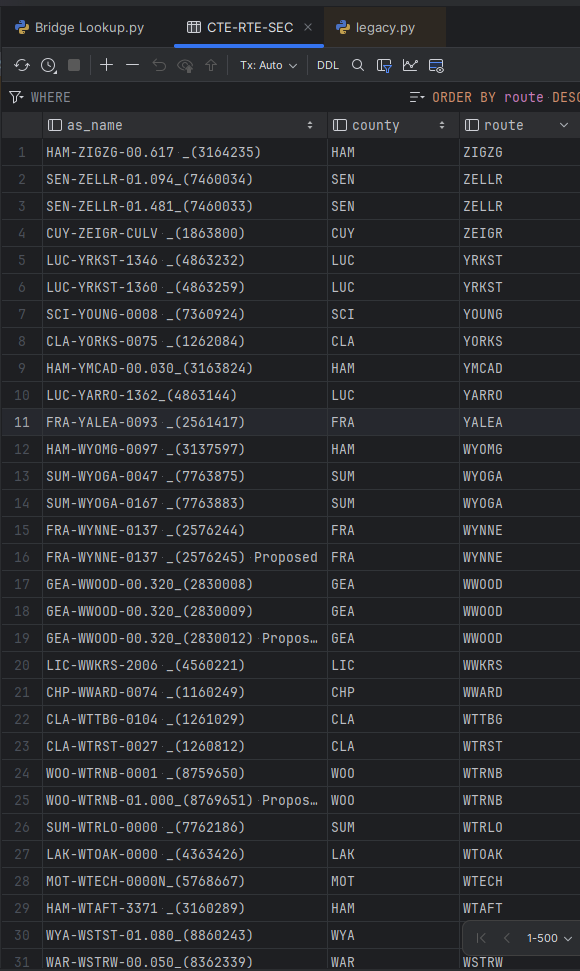

In [ ]:
query = 'SELECT * FROM "Ohio Bridges" WHERE as_name LIKE "FR-%";'

In [ ]:
# Load the filtered data into a Pandas DataFrame
df_filtered = pd.read_sql_query(query, conn)

In [ ]:
df_filtered  # 2561108

In [ ]:
query2 = 'SELECT * FROM "Ohio Bridges" WHERE as_name LIKE "141%";'

In [ ]:
# Load the filtered data into a Pandas DataFrame
df_filtered2 = pd.read_sql_query(query2, conn)

In [ ]:
bridge_id = df_filtered2['as_id'].values[0]
bridge_id

## Additional API Calls

The way these work is they kind of build on each other, the Asset calls  
asset ids (as_ids) which can be used later on for things like getting lists  
of photos, those lists of photos, can then be used to download specific  
photos.

Here are some of the variables Bentley uses and what I could gather they  
represent.

In [ ]:
# {apiType} - always 'api'
# {as_id} - Asset ID - See Asset/Find Asset ID by SFN
# {as_guid} - Asset GUID
# {as_name} - Asset 'common' name - "FRA-00033-0014L_(2500965)" can be fuzzy
# {as_code} - Asset 'code', for Ohio, that's SFN - 2500965
# {af_id} - Asset File (Photos/BR100s, etc.)



# Mostly unused fields?
# {at_id} - Asset Type
# {adf_id} - Asset Detail Field id
# {td_id} - Task Definition ID
# {act_id} - ActivityType ID
# {sch_id} - Schedule activity ID
# {td_id}
# {ast_id} - Asset Activity Type
# {admf_id} - Asset Detail maintenance Field 

In [ ]:
import requests
import re
import pprint

In [ ]:
def get_from_aw(path_template, inputs):
    """
    Builds the full API path by substituting variables into the URL path template,
    makes a GET request to the API with Basic Authentication, and returns the appropriate response.

    :param path_template: The path template string (e.g. "/{apiType}/AssetDetailField/Get/{var1}/{var2}").
    :param inputs: A list of variable values to be substituted into the template in order.
    :param username: Basic Authentication username.
    :param password: Basic Authentication password.
    :return: The response from the API. Returns JSON if possible; otherwise returns raw content.
    """
    base_url = "https://ohiodot-it-api.bentley.com"
    # Ensuring the apiType is always "api"
    path_template = path_template.replace("{apiType}", "api")

    # Replace all placeholders (anything within curly braces) using the inputs list
    placeholders = re.findall(r"\{(.*?)\}", path_template)  # Find all {placeholders}

    if len(placeholders) > len(inputs):
        raise ValueError(
            f"Insufficient inputs provided. Expected {len(placeholders)}, got {len(inputs)}."
        )

    # Replace placeholders in order
    for i, value in enumerate(inputs):
        path_template = path_template.replace(f"{{{placeholders[i]}}}", str(value), 1)

    # Complete the full URL
    full_url = base_url + path_template

    try:
        # Encode the username and password for Basic Authentication
        credentials = f"{username}:{password}"
        encoded_credentials = base64.b64encode(credentials.encode("utf-8")).decode("utf-8")

        # Set the headers for Basic Authentication
        headers = {
            "Authorization": f"Basic {encoded_credentials}",
            "Content-Type": "application/json"  # Specify JSON content type if applicable
        }

        # Perform the GET request with headers
        response = requests.get(full_url, headers=headers)
        response.raise_for_status()  # Raise exception for HTTP errors

        # Handle response based on Content-Type
        content_type = response.headers.get("Content-Type", "").lower()
        if "application/json" in content_type:
            # If response is JSON, parse it and return
            return response.json()
        elif "image" in content_type:
            # If response is an image, return the binary content
            return response.content
        else:
            # Otherwise, return the raw text
            return response.text

    except requests.exceptions.RequestException as e:
        # Handle request errors gracefully
        raise RuntimeError(f"An error occurred while making the API call: {e}") from e

### Asset

In [ ]:
api_path = "/{apiType}/Asset/{as_id}"  # The API defined in the documentation
inputs = [69750]  # The inputs for the API

response = get_from_aw(api_path, inputs)
pprint.pp(response)  # Call the API and print the response

#### Find Asset ID by SFN

In [ ]:
api_path = "/{apiType}/Asset/GetAssetByAsCode/{as_code}"  # Basically by SFN
inputs = ['0130192']  # Inputs must match placeholders in order

response = get_from_aw(api_path, inputs)
pprint.pp(response['data']['as_id'])  # JSON response data

### AssetDetailField

In [ ]:
api_path = "/{apiType}/AssetDetailField/GetFieldsByAsId/{as_id}"
inputs = [69750]  # Inputs must match placeholders in order

response = get_from_aw(api_path, inputs)
pprint.pp(response)

### AssetElements

In [ ]:
api_path = "/AssetElements"
inputs = []  # Inputs must match placeholders in order

response = get_from_aw(api_path, inputs)
pprint.pp(response)

### AssetFile

In [ ]:
api_path = "/{apiType}/AssetFile/GetByAssetId/{as_id}"
inputs = [69750]  # Inputs must match placeholders in order

response = get_from_aw(api_path, inputs)
pprint.pp(response)

In [ ]:
from IPython.display import Image, display
from io import BytesIO

api_path = "/{apiType}/AssetFile/GetAssetCoverImage/{as_id}"
inputs = [69750]

response = get_from_aw(api_path, inputs)
display(Image(response))

In [ ]:
api_path = "/{apiType}/AssetFile/Download/{af_id}"
inputs = [1027716]

response = get_from_aw(api_path, inputs)
display(Image(response))

In [ ]:
api_path = "/{apiType}/AssetFile/Download/{af_id}?get_as_thumbnail=true"
inputs = [1027716]

response = get_from_aw(api_path, inputs)
display(Image(response))

In [ ]:
api_path = "/{apiType}/AssetFile/GetAssetFileFieldMap/{af_id}"
inputs = [1027716]

response = get_from_aw(api_path, inputs)
pprint.pp(response)

In [ ]:
api_path = "/{apiType}/AssetFile/GetByAssetId/{as_id}"
inputs = [69750]  # Inputs must match placeholders in order

response = get_from_aw(api_path, inputs)

for file in response['data']:
    print(file['af_id'])
    api_path = "/{apiType}/AssetFile/Download/{af_id}?get_as_thumbnail=true"
    inputs = [file['af_id']]

    response = get_from_aw(api_path, inputs)
    display(Image(response))

### AssetFileCategory

In [ ]:
api_path = "/{apiType}/AssetFileCategory"
inputs = []

response = get_from_aw(api_path, inputs)
pprint.pp(response)

### AssetFilesFieldMap

### AssetTasks

In [ ]:
api_path = "/AssetTasks"
inputs = []

response = get_from_aw(api_path, inputs)
pprint.pp(response[0])

In [ ]:
api_path = "/{apiType}/AssetStatus"
inputs = []

response = get_from_aw(api_path, inputs)
pprint.pp(response)

In [ ]:
# Close the connection
conn.close()

# Example of Extracting Data and Rendering a Model with It

In [ ]:
import cadquery as cq

In [ ]:
class CADObject:
    def __init__(self, length=1.0, width=1.0, height=1.0):
        self.length = length
        self.width = width
        self.height = height

In [ ]:
def generate_cad_model(cad_object):
    """
    Generate a 3D model (e.g., a cube) based on the CADObject's dimensions.
    """
    model = cq.Workplane("XY").box(
        cad_object.length, cad_object.width, cad_object.height
    )
    return model


In [ ]:
def export_stl(model, filename="model.stl"):
    """
    Export the CAD model to an STL file for rendering.
    """
    cq.exporters.export(model, filename)

In [ ]:
from nicegui import ui
import os
from cadquery import exporters
# from trimesh.exchange.stl import load_mesh  # Optional: For rendering with three.js

# Define the CAD object
cad_object = CADObject()

# Function to update the 3D model when sliders change
def update_model():
    model = generate_cad_model(cad_object)
    export_stl(model, "assets/model.stl")  # Save STL file dynamically
    scene.update()  # Refresh the 3D scene

# NiceGUI app
def main():
    ui.label("Adjust 3D Model:").classes("text-lg")

    with ui.row():
        ui.slider(min=1.0, max=10.0, step=0.1, value=cad_object.length, label="Length", on_change=lambda e: setattr(cad_object, "length", e.value) or update_model())
        ui.slider(min=1.0, max=10.0, step=0.1, value=cad_object.width, label="Width", on_change=lambda e: setattr(cad_object, "width", e.value) or update_model())
        ui.slider(min=1.0, max=10.0, step=0.1, value=cad_object.height, label="Height", on_change=lambda e: setattr(cad_object, "height", e.value) or update_model())

    # Render 3D Scene Using NiceGUI's `scene` component
    with ui.card():
        scene = ui.scene().classes("w-full h-96")
        scene.mesh('assets/model.stl')  # STL loading support in NiceGUI

ui.run(title="Dynamic 3D CAD Viewer")